In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

import os

In [2]:
root = os.getcwd()
path_plot = "/home/peiretti/fair-clustering/plots/lfw"

In [3]:
# Load data
X = np.load(root + "/matrix.npy")              # shape: (n_samples, n_features)
person_ids = np.load(root + "/person_ids.npy") # shape: (n_samples,)
person_names = np.load(root + "/person_names.npy")  # may be aligned with unique IDs or with rows
gender = np.load(root + "/gender.npy")         # 0 = Male, 1 = Female

print("X shape:", X.shape)
print("person_ids shape:", person_ids.shape)
print("gender shape:", gender.shape)
print("person_names shape:", person_names.shape)

X shape: (13233, 1850)
person_ids shape: (13233,)
gender shape: (13233,)
person_names shape: (5749,)


In [10]:
df = pd.DataFrame({
    "person_id": person_ids,
    "gender": gender
})

df["gender_label"] = df["gender"].map({0: "Male", 1: "Female"})
print(df.head())

   person_id  gender gender_label
0       5360       0         Male
1       3434       0         Male
2       3807       0         Male
3         26       0         Male
4       3957       1       Female


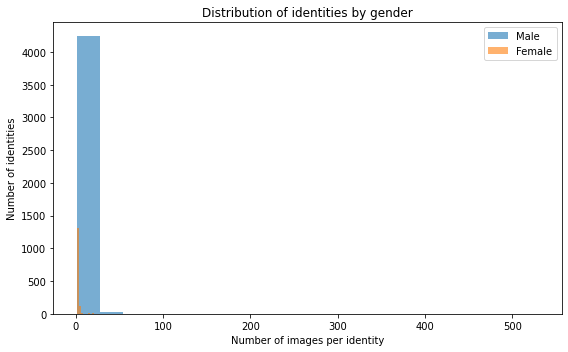

In [11]:
# Assign one gender to each identity by majority vote
identity_gender = (
    df.groupby("person_id")["gender"]
      .agg(lambda x: x.value_counts().idxmax())
)

# Number of images per identity
images_per_identity = df.groupby("person_id").size()

identity_df = pd.DataFrame({
    "person_id": images_per_identity.index,
    "n_images": images_per_identity.values,
    "gender": identity_gender.values
})
identity_df["gender_label"] = identity_df["gender"].map({0: "Male", 1: "Female"})

# Histogram of number of images per identity by gender
plt.figure(figsize=(8, 5))

plt.hist(
    identity_df.loc[identity_df["gender"] == 0, "n_images"],
    bins=20,
    alpha=0.6,
    label="Male"
)
plt.hist(
    identity_df.loc[identity_df["gender"] == 1, "n_images"],
    bins=20,
    alpha=0.6,
    label="Female"
)

plt.xlabel("Number of images per identity")
plt.ylabel("Number of identities")
plt.title("Distribution of identities by gender")
plt.legend()
plt.tight_layout()
plt.show()

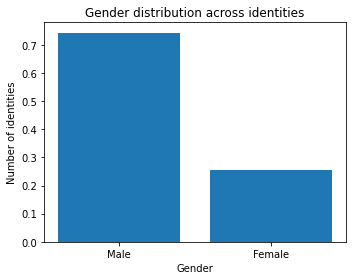

In [28]:
identity_gender_counts = identity_df["gender_label"].value_counts()

plt.figure(figsize=(5, 4))
plt.bar(identity_gender_counts.index, identity_gender_counts.values/np.sum(identity_gender_counts.values))
plt.xlabel("Gender")
plt.ylabel("Number of identities")
plt.title("Gender distribution across identities")
plt.tight_layout()
plt.show()

In [17]:
np.unique(gender, return_counts=True)

(array([0, 1]), array([10268,  2965]))

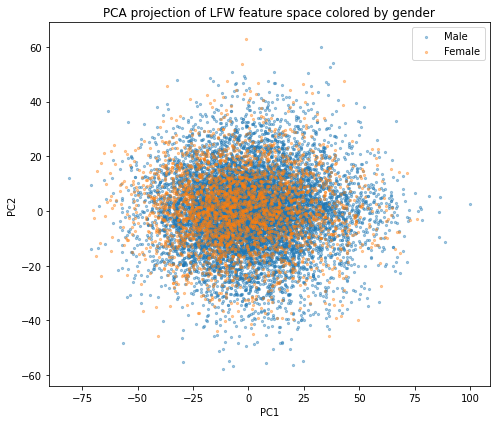

In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,6))

plt.scatter(
    X_pca[gender==0,0],
    X_pca[gender==0,1],
    s=5,
    alpha=0.4,
    label="Male"
)

plt.scatter(
    X_pca[gender==1,0],
    X_pca[gender==1,1],
    s=5,
    alpha=0.4,
    label="Female"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection of LFW feature space colored by gender")
plt.legend()
plt.tight_layout()
plt.savefig(path_plot + "/gender_feature_space.png", dpi=300, bbox_inches="tight")

array([ True,  True,  True, ...,  True,  True,  True])